In [ ]:
import k_fail_GPS
import k_fail_MBTR
import BB_wrapper
import k_fail_prediction

import torch

# Wrapper

In [2]:
cap_n_problems = 12

cutest_wrapper = BB_wrapper.BB_cutest_collection(write_to_file="cutest_problem_selection.txt", max_dim=100, cap_n_problems=cap_n_problems,
problem_names= [
    "SISSER",
    "CHWIRUT2LS",
    "DENSCHNB",
    "GBRAINLS",
    "MGH10LS",
    "QING",
    "BOX3",
    "DENSCHNC",
    "LANCZOS3LS",
    "GAUSS1LS",
    "COOLHANSLS",
    "LOGHAIRY"
])

loading problems...
0/12
loaded 12 problems


In [3]:
# evaluating n problem functions
for i in range(cap_n_problems):
    p = cutest_wrapper.problems[i]
    f = cutest_wrapper.problem_functions[i]
    print(f"idx: {i} | {p.name} | n: {p.n}: {f(torch.from_numpy(p.x0))}")

idx: 0 | SISSER | n: 2: 3.02030030003
idx: 1 | CHWIRUT2LS | n: 3: 14794.790154797307
idx: 2 | DENSCHNB | n: 2: 6.0
idx: 3 | GBRAINLS | n: 2: 41.0311021275977
idx: 4 | MGH10LS | n: 3: 4515242701191391.0
idx: 5 | QING | n: 100: 328350.0
idx: 6 | BOX3 | n: 3: 1.8845685008804969
idx: 7 | DENSCHNC | n: 2: 889.3031475218829
idx: 8 | LANCZOS3LS | n: 6: 269.7514694982056
idx: 9 | GAUSS1LS | n: 8: 7371.720578441935
idx: 10 | COOLHANSLS | n: 9: 902930.45122
idx: 11 | LOGHAIRY | n: 2: 6.552519791934271


# Settings

In [4]:
problem_idx = 5
k = 1
num_cpus = 4

# Different variations

In [5]:
# non exploitative GPS

GPS_non_expl_k_fail_wrapper = BB_wrapper.BB_k_fail_wrapper(cutest_wrapper.problem_functions[problem_idx], k*torch.ones((1024, 2), dtype=torch.int16), num_cpus)

alg = k_fail_GPS.GPS_k_fail(torch.from_numpy(cutest_wrapper.problems[problem_idx].x0), GPS_non_expl_k_fail_wrapper, delta=1, tao=0.5, prediction_software=k_fail_prediction.constant_prediction_software(k), log_file_path="alg_logs/GPS/testing_non_expl.txt", use_opportunistic_cpu_exploitation=False)

alg.log_current(message=f"k={k}")
for i in range(100):
    alg.step_default(random_rotate=True)

In [6]:
# exploitative GPS

GPS_expl_k_fail_wrapper = BB_wrapper.BB_k_fail_wrapper(cutest_wrapper.problem_functions[problem_idx], k*torch.ones((1024, 2), dtype=torch.int16), num_cpus)

alg = k_fail_GPS.GPS_k_fail(torch.from_numpy(cutest_wrapper.problems[problem_idx].x0), GPS_expl_k_fail_wrapper, delta=1, tao=0.5, prediction_software=k_fail_prediction.constant_prediction_software(k), log_file_path="alg_logs/GPS/testing_expl.txt", use_opportunistic_cpu_exploitation=True)

alg.log_current(message=f"k={k}")
for i in range(100):
    alg.step_default(random_rotate=True)

In [7]:
# non exploitative MBTR

MBTR_non_expl_k_fail_wrapper = BB_wrapper.BB_k_fail_wrapper(cutest_wrapper.problem_functions[problem_idx], k*torch.ones((1024, 2), dtype=torch.int16), num_cpus)

alg = k_fail_MBTR.MBTR_k_fail(torch.from_numpy(cutest_wrapper.problems[problem_idx].x0), MBTR_non_expl_k_fail_wrapper, delta=1, mu=1e-1, eta=0.1, gamma=0.5, eps_stop=1e-1, prediction_software=k_fail_prediction.constant_prediction_software(k), log_file_path="alg_logs/MBTR/testing_non_expl.txt", preferred_model_order=2, use_opportunistic_cpu_exploitation=False)

alg.log_current()
for i in range(100):
    if alg.step_default():
        break

KeyboardInterrupt: 

In [ ]:
# exploitative MBTR

MBTR_expl_k_fail_wrapper = BB_wrapper.BB_k_fail_wrapper(cutest_wrapper.problem_functions[problem_idx], k*torch.ones((1024, 2), dtype=torch.int16), num_cpus)

alg = k_fail_MBTR.MBTR_k_fail(torch.from_numpy(cutest_wrapper.problems[problem_idx].x0), MBTR_expl_k_fail_wrapper, delta=1, mu=1e-1, eta=0.1, gamma=0.5, eps_stop=1e-1, prediction_software=k_fail_prediction.constant_prediction_software(k), log_file_path="alg_logs/MBTR/testing_expl.txt", preferred_model_order=2, use_opportunistic_cpu_exploitation=True,
                              opportunistic_cpu_exploitation_manual_point_limit = int(6 * (10 * cutest_wrapper.problems[problem_idx].n) ** 0.5))

alg.log_current()
for i in range(100):
    if alg.step_default():
        break

QUAD torch.Size([103, 100]) torch.Size([103])
QUAD torch.Size([102, 100]) torch.Size([102])
QUAD torch.Size([103, 100]) torch.Size([103])
QUAD torch.Size([104, 100]) torch.Size([104])
QUAD torch.Size([106, 100]) torch.Size([106])
QUAD torch.Size([108, 100]) torch.Size([108])
QUAD torch.Size([109, 100]) torch.Size([109])
QUAD torch.Size([110, 100]) torch.Size([110])
QUAD torch.Size([102, 100]) torch.Size([102])
QUAD torch.Size([103, 100]) torch.Size([103])
QUAD torch.Size([104, 100]) torch.Size([104])
QUAD torch.Size([105, 100]) torch.Size([105])
QUAD torch.Size([106, 100]) torch.Size([106])
QUAD torch.Size([107, 100]) torch.Size([107])
QUAD torch.Size([109, 100]) torch.Size([109])
QUAD torch.Size([111, 100]) torch.Size([111])
QUAD torch.Size([113, 100]) torch.Size([113])
QUAD torch.Size([115, 100]) torch.Size([115])
QUAD torch.Size([116, 100]) torch.Size([116])
QUAD torch.Size([117, 100]) torch.Size([117])
QUAD torch.Size([118, 100]) torch.Size([118])
QUAD torch.Size([120, 100]) torch.

KeyboardInterrupt: 

In [ ]:
# exploitative MBTR with linear

MBTR_expl_k_fail_wrapper_lin = BB_wrapper.BB_k_fail_wrapper(cutest_wrapper.problem_functions[problem_idx], k*torch.ones((1024, 2), dtype=torch.int16), num_cpus)

alg = k_fail_MBTR.MBTR_k_fail(torch.from_numpy(cutest_wrapper.problems[problem_idx].x0), MBTR_expl_k_fail_wrapper_lin, delta=1, mu=1e-1, eta=0.1, gamma=0.5, eps_stop=1e-1, prediction_software=k_fail_prediction.constant_prediction_software(k), log_file_path="alg_logs/MBTR/testing_expl_lin.txt", preferred_model_order=1, use_opportunistic_cpu_exploitation=True,
                              opportunistic_cpu_exploitation_manual_point_limit = int(6 * (10 * cutest_wrapper.problems[problem_idx].n) ** 0.5))

alg.log_current()
for i in range(100):
    if alg.step_default():
        break

# Plotting results

for now I will just do convergence plots for one problem

In [6]:
import re
import numpy as np
import matplotlib.pyplot as plt

def parse_log(filepath):
    fx, n_func, n_1batch, n_batch = [], [], [], []

    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('k'):
                continue

            cols = line.split('|')
            if len(cols) < 5:
                continue

            try:
                fx.append(float(cols[2].strip()))        # f(x) is column index 2
            except ValueError:
                continue

            counters_match = re.search(r'\[(\d+),\s*(\d+),\s*(\d+),\s*(\d+)\]', cols[4])
            if not counters_match:
                continue
            n_func.append(int(counters_match.group(1)))
            n_1batch.append(int(counters_match.group(3)))
            n_batch.append(int(counters_match.group(4)))

    return (np.array(fx),
            np.array(n_func),
            np.array(n_1batch),
            np.array(n_batch))

def plot_convergence(filepath1, filepath2, show_excl_1batch=True):
    fx1, n_func1, n_1batch1, n_batch1 = parse_log(filepath1)
    fx2, n_func2, n_1batch2, n_batch2 = parse_log(filepath2)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].step(n_func1, fx1, where='post', label=filepath1)
    axes[0].step(n_func2, fx2, where='post', label=filepath2)
    axes[0].set_xlabel('function calls')
    axes[0].set_ylabel('f(x)')
    axes[0].set_yscale('log')
    axes[0].legend(fontsize=8)

    axes[1].step(n_batch1, fx1, where='post', label=f'{filepath1} all batch', color='C0')
    axes[1].step(n_batch2, fx2, where='post', label=f'{filepath2} all batch', color='C1')

    if show_excl_1batch:
        axes[1].step(n_batch1 - n_1batch1, fx1, where='post', label=f'{filepath1} excl. 1-batch', color='green')
        axes[1].step(n_batch2 - n_1batch2, fx2, where='post', label=f'{filepath2} excl. 1-batch', color='red')

    axes[1].set_xlabel('batch calls')
    axes[1].set_ylabel('f(x)')
    axes[1].set_yscale('log')
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

# GPS vs MBTR (not exploitative)

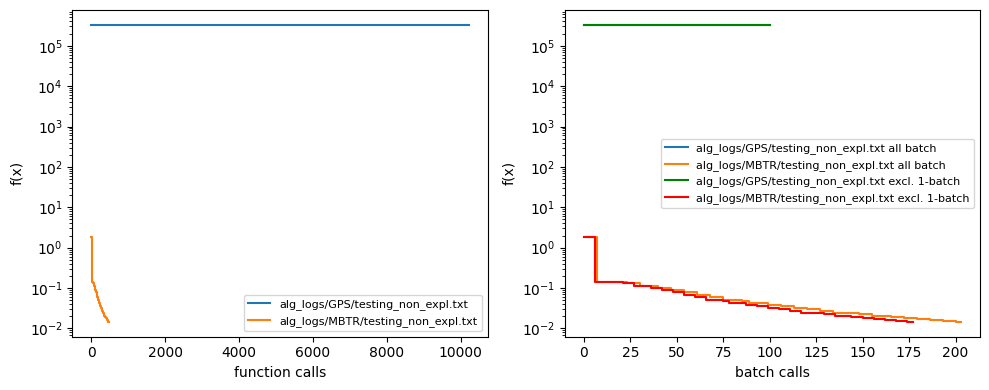

In [9]:
plot_convergence("alg_logs/GPS/testing_non_expl.txt", "alg_logs/MBTR/testing_non_expl.txt")

# GPS vs MBTR (exploitative)

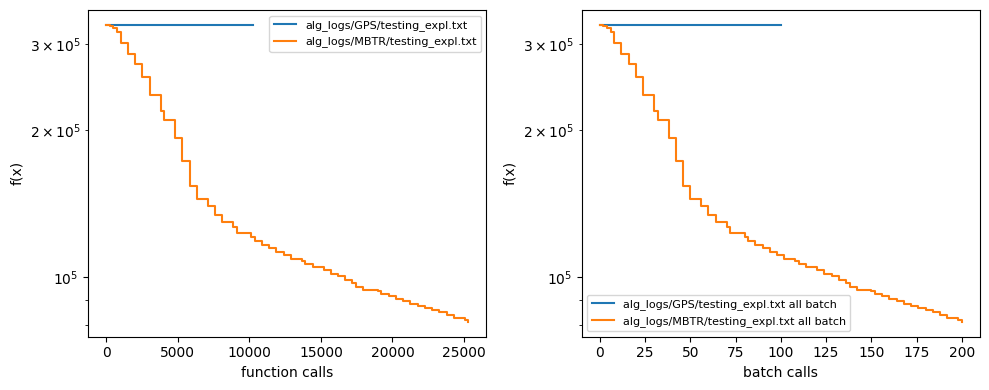

In [10]:
plot_convergence("alg_logs/GPS/testing_expl.txt", "alg_logs/MBTR/testing_expl.txt",show_excl_1batch=False)

# GPS (expl) vs MBTR (non)

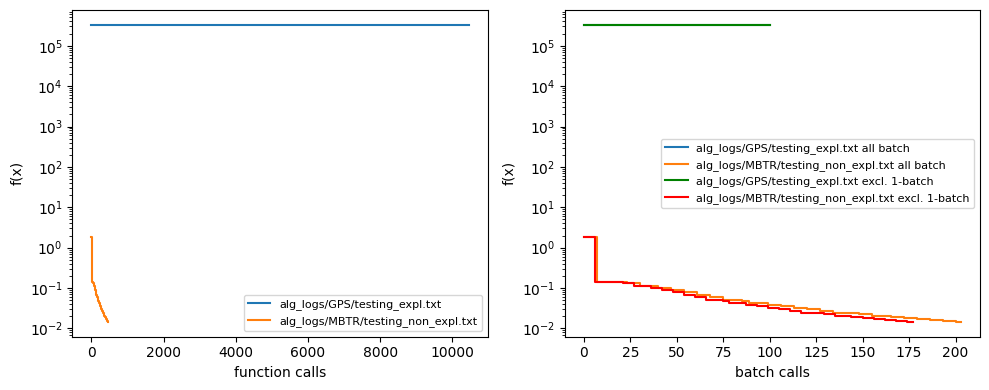

In [11]:
plot_convergence("alg_logs/GPS/testing_expl.txt", "alg_logs/MBTR/testing_non_expl.txt")

# GPS (non) vs MBTR (expl)

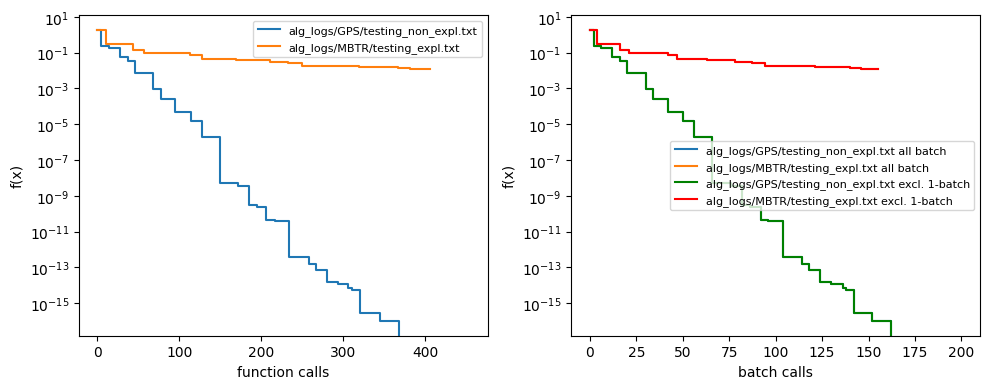

In [119]:
plot_convergence("alg_logs/GPS/testing_non_expl.txt", "alg_logs/MBTR/testing_expl.txt")

# GPS (expl) vs GPS (non)

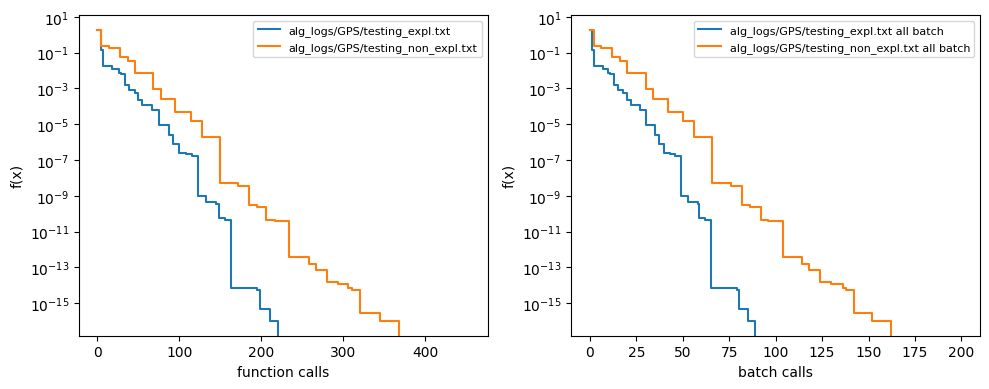

In [120]:
plot_convergence("alg_logs/GPS/testing_expl.txt", "alg_logs/GPS/testing_non_expl.txt", show_excl_1batch=False)

# MBTR (expl) vs MBTR (non)

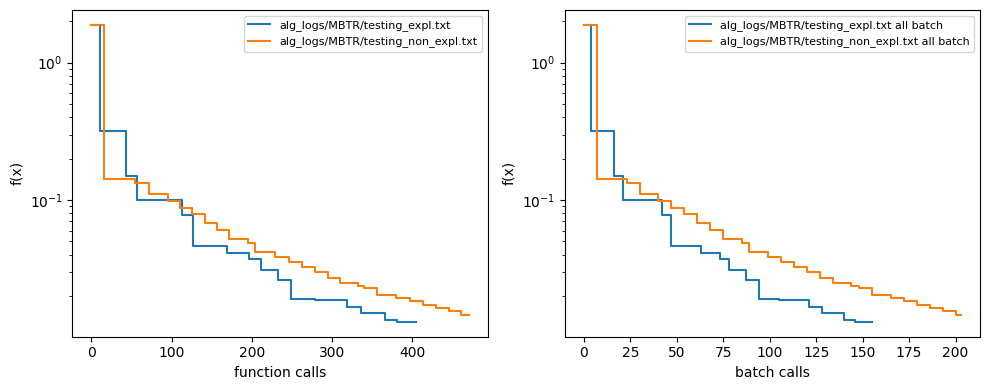

In [122]:
plot_convergence("alg_logs/MBTR/testing_expl.txt", "alg_logs/MBTR/testing_non_expl.txt",show_excl_1batch=False)

# MBTR quad (expl) vs MBTR lin (expl)

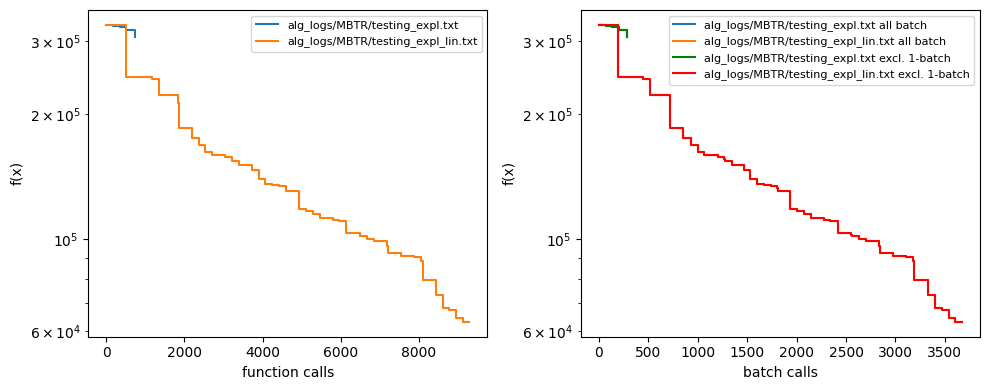

In [7]:
plot_convergence("alg_logs/MBTR/testing_expl.txt", "alg_logs/MBTR/testing_expl_lin.txt")

In [8]:
for i in range(1000000):
    cutest_wrapper.problem_functions[5](torch.rand(100))

In [10]:
import models
models.get_quad_model_and_solution(torch.rand((400, 100)), torch.ones(400), 1.0)

(tensor([0.4387, 0.9383, 0.7561, 0.9474, 0.8265, 0.2829, 0.0898, 0.4245, 0.1015,
         0.4222, 0.1499, 0.2546, 0.4516, 0.2321, 0.3866, 0.4959, 0.8570, 0.4018,
         0.3121, 0.5729, 0.9547, 0.2971, 0.1565, 0.1527, 0.7618, 0.7585, 0.1753,
         0.5659, 0.6381, 0.6353, 0.8416, 0.7665, 0.7267, 0.2052, 0.4025, 0.6703,
         0.8991, 0.3756, 0.8257, 0.4537, 0.0173, 0.2178, 0.2938, 0.9640, 0.9769,
         0.0741, 0.2732, 0.0840, 0.5038, 0.7689, 0.7443, 0.7821, 0.2710, 0.8537,
         0.2183, 0.4194, 0.5882, 0.6018, 0.2775, 0.5355, 0.9832, 0.1613, 0.2347,
         0.5827, 0.4279, 0.2937, 0.0242, 0.9888, 0.9494, 0.6858, 0.1194, 0.2284,
         0.8091, 0.3141, 0.9013, 0.0189, 0.9327, 0.8441, 0.3688, 0.6153, 0.3871,
         0.0043, 0.4334, 0.5823, 0.3308, 0.3941, 0.0195, 0.1981, 0.1876, 0.4021,
         0.9022, 0.7258, 0.5496, 0.6873, 0.7896, 0.7804, 0.0696, 0.1956, 0.4031,
         0.9529], dtype=torch.float64),
 np.float64(1.0),
 tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.